In [3]:
!pip install plotly

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
import pandas as pd

In [7]:
# Replace with your actual dataset or data source
data = {
    'Category': ['Category 1', 'Category 1', 'Category 2', 'Category 2', 'Category 3'],
    'Subcategory': ['Subcategory 1A', 'Subcategory 1B', 'Subcategory 2A', 'Subcategory 2B', 'Subcategory 3A'],
    'Value': [10, 20, 30, 40, 50]
}
df = pd.DataFrame(data)

In [8]:
df

,Category,Subcategory,Value
0,Category 1,Subcategory 1A,10
1,Category 1,Subcategory 1B,20
2,Category 2,Subcategory 2A,30
3,Category 2,Subcategory 2B,40
4,Category 3,Subcategory 3A,50


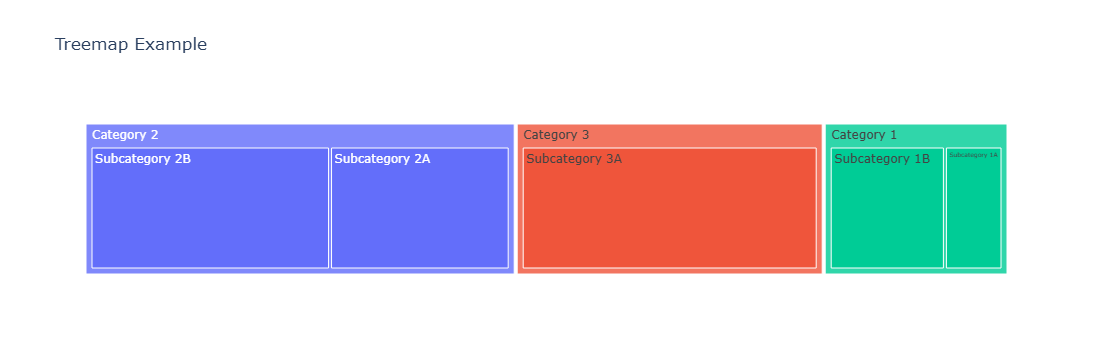

In [9]:
fig = px.treemap(df,
                 path=['Category', 'Subcategory'],  # Define hierarchical structure
                 values='Value',  # Size of each rectangle
                 title='Treemap Example')  # Title of the treemap
fig.show()

In [10]:
data1 = {
    'Category' : ['Electronics','Electronics','Electronics','Furniture','Furniture','Furniture','Cloths','Cloths','Cloths'],
    'Subcategory' : ['Laptops','Smartphone','Tablet','Chairs','Tables','Sofas','Men','Women','Kids'],
    'Values' : [12000,8000,3000,5000,4000,2000,7000,9000,4000] }
df2 = pd.DataFrame(data1)
df2

,Category,Subcategory,Values
0,Electronics,Laptops,12000
1,Electronics,Smartphone,8000
2,Electronics,Tablet,3000
3,Furniture,Chairs,5000
4,Furniture,Tables,4000
5,Furniture,Sofas,2000
6,Cloths,Men,7000
7,Cloths,Women,9000
8,Cloths,Kids,4000


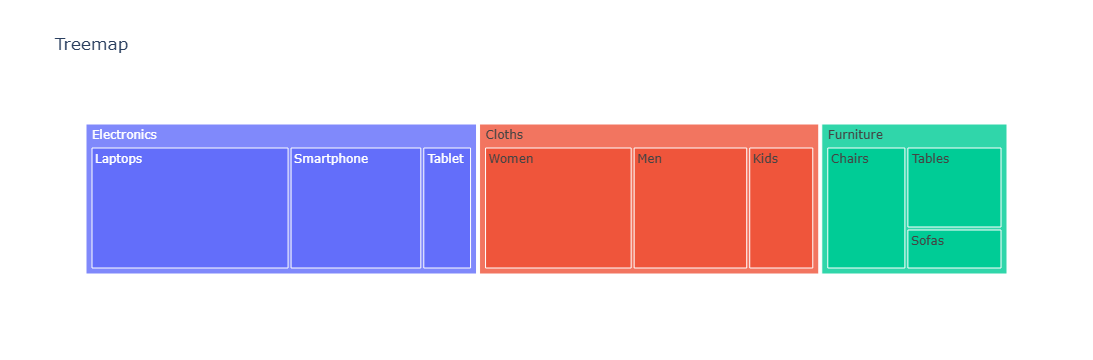

In [13]:
fig = px.treemap(df2,
                 path=['Category','Subcategory'],
                 values='Values',
                 title='Treemap ')
fig.show()

In [14]:
sales_df = pd.read_csv('sales_data.csv')
sales_df.head()

,S. No.,Date,Category,Subcategory,Sales
0,0,Q1,Peripherals,Accessories,3447
1,1,Q1,Laptops,Components,3385
2,2,Q1,Desktops,Software Suites,1885
3,3,Q1,Software,Components,4169
4,4,Q1,Software,Components,3766


In [18]:
pivot_table = sales_df.pivot_table(values='Sales',index='Category',columns='Date',aggfunc='sum')

In [20]:
print(pivot_table)

Date             Q1      Q2      Q3      Q4
Category                                   
Desktops     425745  501959  428052  418003
Laptops      457961  455228  440636  443342
Peripherals  475422  417795  408944  446609
Software     487430  407169  431904  504968


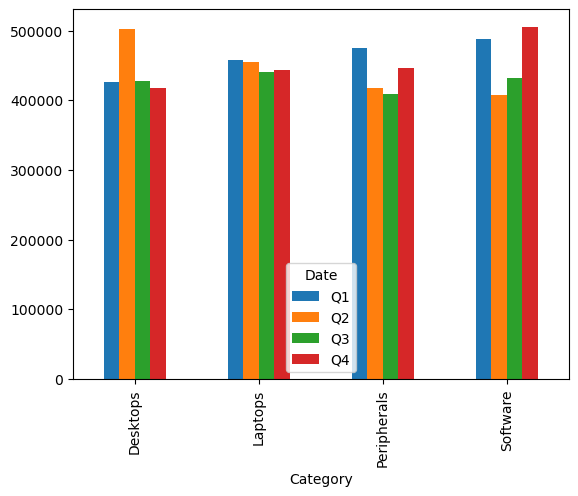

In [19]:
# pivot_table = data.pivot_table(values='ValueColumn', index='RowIndexColumn', columns='ColumnIndexColumn', aggfunc='sum')


pivot_table.plot(kind='bar')
plt.show()

In [22]:
# Total sales: Category down the rows, Quarter across the columns
pivot_table = sales_df.pivot_table(
    values='Sales',
    index='Category',
    columns='Date',
    aggfunc='sum'
)

print(pivot_table)

Date             Q1      Q2      Q3      Q4
Category                                   
Desktops     425745  501959  428052  418003
Laptops      457961  455228  440636  443342
Peripherals  475422  417795  408944  446609
Software     487430  407169  431904  504968


In [23]:
pivot2 = sales_df.pivot_table(
    values='Sales',
    index=['Category', 'Subcategory'],
    columns='Date',
    aggfunc='sum'
)
print(pivot2)

Date                             Q1      Q2      Q3      Q4
Category    Subcategory                                    
Desktops    Accessories      164478  149993  130460  159467
            Components       128778  189853  167276  140734
            Software Suites  132489  162113  130316  117802
Laptops     Accessories      137341  162433  125859  143585
            Components       179765  159155  155598  163166
            Software Suites  140855  133640  159179  136591
Peripherals Accessories      183765  147431  148211  152422
            Components       112025  116134  148553  136038
            Software Suites  179632  154230  112180  158149
Software    Accessories      119768  157779  149067  191119
            Components       209401  112653  148794  135589
            Software Suites  158261  136737  134043  178260


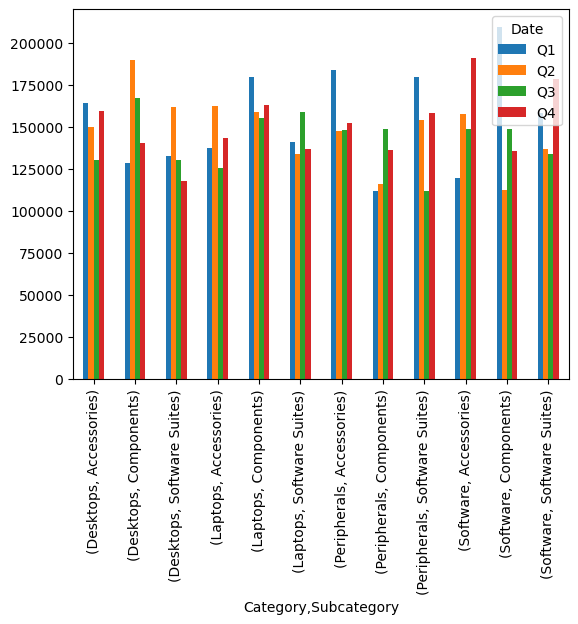

In [24]:
pivot2.plot(kind='bar')
plt.show()

In [25]:
# Add row and column totals
pivot3 = sales_df.pivot_table(
    values='Sales',
    index='Category',
    columns='Date',
    aggfunc='sum',
    margins=True,
    margins_name='Total'
)
print(pivot3)

Date              Q1       Q2       Q3       Q4    Total
Category                                                
Desktops      425745   501959   428052   418003  1773759
Laptops       457961   455228   440636   443342  1797167
Peripherals   475422   417795   408944   446609  1748770
Software      487430   407169   431904   504968  1831471
Total        1846558  1782151  1709536  1812922  7151167


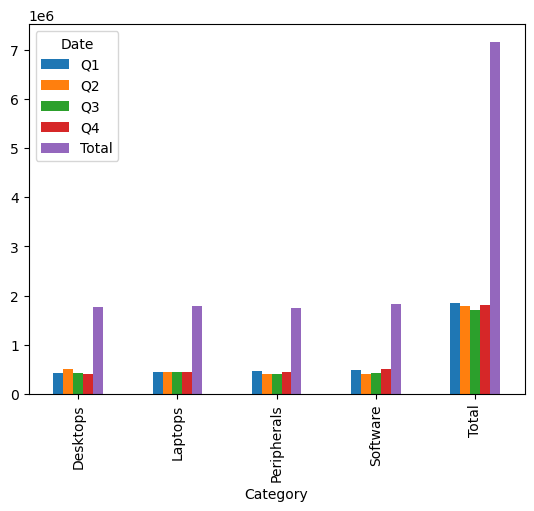

In [26]:
pivot3.plot(kind='bar')
plt.show()

In [27]:
# Fill empty combinations with 0 instead of NaN
pivot5 = sales_df.pivot_table(
    values='Sales',
    index='Category',
    columns='Subcategory',
    aggfunc='sum',
    fill_value=0
)
print(pivot5)

Subcategory  Accessories  Components  Software Suites
Category                                             
Desktops          604398      626641           542720
Laptops           569218      657684           570265
Peripherals       631829      512750           604191
Software          617733      606437           607301


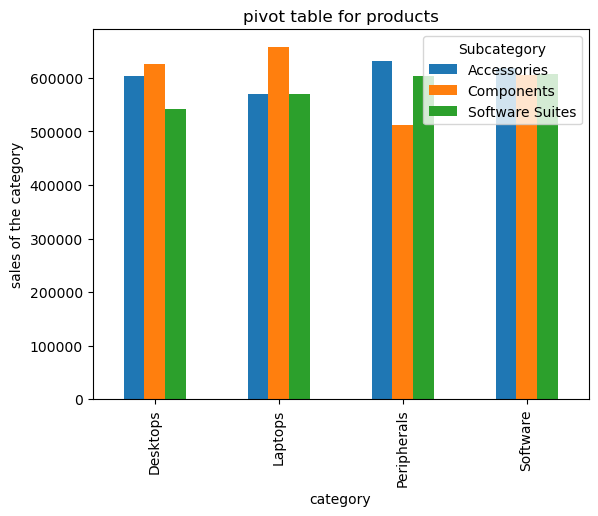

In [28]:
pivot5.plot(kind='bar')
plt.title('pivot table for products')
plt.xlabel('category')
plt.ylabel('sales of the category')
plt.show()


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define the parameters
num_quarters = 4
num_categories = 4
num_subcategories = 3
num_samples = num_quarters * num_categories * num_subcategories*50

# Generate sample sales data
np.random.seed(40)

# Creating sample data
dates = np.repeat(['Q1','Q2','Q3','Q4'], 50*num_categories * num_subcategories)
categories = np.tile(np.random.choice(['Laptops', 'Desktops', 'Peripherals', 'Software'], size=num_quarters*50), num_categories * num_subcategories)
subcategories = np.tile(np.random.choice(['Accessories', 'Components', 'Software Suites'], size=num_quarters*50), num_categories * num_subcategories)
sales_values = np.random.randint(1000, 5000, size=num_samples)

# Create DataFrame
df = pd.DataFrame({
    'Date': dates,
    'Category': categories,
    'Subcategory': subcategories,
    'Sales': sales_values
})

In [30]:
# Create pivot table
pivot_table = df.pivot_table(index='Date', columns=['Category','Subcategory'], values='Sales', aggfunc='sum')

In [ ]:
# Plotting a pivot chart
pivot_table.plot(kind='bar', figsize=(14, 8))
plt.title('Sales Summary of IT Products by Category and Subcategory')
plt.xlabel('Quarters')
plt.ylabel('Total Sales')
plt.grid(False)
plt.legend(title=('Category', 'Subcategory'), bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()